In [3]:
# put this in a cell
import numpy as np
from PIL import Image, ImageOps

def make_25D_from_pgm(pgm_path, out_height_png="terrain_heightmap.png",
                      out_obj=None, res_m=0.05,
                      wall_height=3.0, base_height=0.2,
                      wall_thresh=0.7, und_amp=0.25, und_pass=3,
                      rng_seed=42):
    img = Image.open(pgm_path)
    img = ImageOps.autocontrast(img)
    arr = np.array(img).astype(np.float32)
    free = arr / max(arr.max(), 255.0)
    free_inv = 1.0 - free
    free_inv = (free_inv - free_inv.min()) / (free_inv.max() - free_inv.min() + 1e-9)

    H = base_height * (1.0 - free_inv) + wall_height * (free_inv > wall_thresh)

    rng = np.random.default_rng(rng_seed)
    noise = rng.normal(0, 1, size=H.shape)
    for _ in range(und_pass):
        noise = (np.roll(noise,1,0)+noise+np.roll(noise,-1,0))/3.0
        noise = (np.roll(noise,1,1)+noise+np.roll(noise,-1,1))/3.0
    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-9)
    und = und_amp * (noise - 0.5)
    H = H + und * (free_inv < wall_thresh)

    Hn = (H - H.min()) / (H.max() - H.min() + 1e-9)
    Image.fromarray((Hn*65535).astype(np.uint16), mode="I;16").save(out_height_png)
    print(f"[✓] Wrote heightmap: {out_height_png}")

    if out_obj:
        h, w = H.shape
        with open(out_obj, "w") as f:
            for y in range(h):
                for x in range(w):
                    f.write(f"v {x*res_m:.4f} {y*res_m:.4f} {H[y,x]:.4f}\n")
            def idx(x,y): return y*w + x + 1
            for y in range(h-1):
                for x in range(w-1):
                    v0, v1, v2, v3 = idx(x,y), idx(x+1,y), idx(x+1,y+1), idx(x,y+1)
                    f.write(f"f {v0} {v1} {v2}\n")
                    f.write(f"f {v0} {v2} {v3}\n")
        print(f"[✓] Wrote mesh OBJ: {out_obj}")
    return H


In [4]:
H = make_25D_from_pgm("hamr_maze_big.pgm",
                      out_height_png="terrain_heightmap.png",
                      out_obj="terrain_mesh.obj",
                      res_m=0.05)


[✓] Wrote heightmap: terrain_heightmap.png
[✓] Wrote mesh OBJ: terrain_mesh.obj


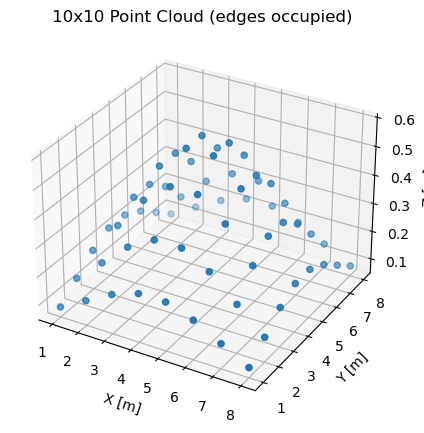

('pointcloud_10x10.csv', 'pointcloud_10x10.ply', (64, 3))

In [10]:
# Recreate after kernel reset (stateful notebook reset).

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

cells_x = 10
cells_y = 10
res_m = 1.0

occ = np.zeros((cells_y, cells_x), dtype=np.uint8)
occ[0,:] = 1; occ[-1,:] = 1; occ[:,0] = 1; occ[:,-1] = 1

yy, xx = np.mgrid[0:cells_y, 0:cells_x]
X = xx * res_m
Y = yy * res_m
cx, cy = (cells_x-1)/2.0*res_m, (cells_y-1)/2.0*res_m
amp_m = 0.6
sigma_m = 2.5
R2 = ((X - cx)**2 + (Y - cy)**2) / (2.0 * sigma_m**2)
H = amp_m * np.exp(-R2)

mask_free = occ == 0
pts = np.stack([X[mask_free], Y[mask_free], H[mask_free]], axis=1)

csv_path = "pointcloud_10x10.csv"
pd.DataFrame(pts, columns=["x","y","z"]).to_csv(csv_path, index=False)

ply_path = "pointcloud_10x10.ply"
with open(ply_path, "w") as f:
    f.write("ply\nformat ascii 1.0\n")
    f.write(f"element vertex {pts.shape[0]}\n")
    f.write("property float x\nproperty float y\nproperty float z\n")
    f.write("end_header\n")
    for x,y,z in pts:
        f.write(f"{x:.4f} {y:.4f} {z:.4f}\n")

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=20)
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]"); ax.set_zlabel("Z [m]")
ax.set_title("10x10 Point Cloud (edges occupied)")
plt.show()

csv_path, ply_path, pts.shape


In [ ]:
# Create a blank PGM occupancy map with occupied outer edges.
# Convention (ROS map_server style):
#   0   = occupied (black)
#   254 = free (white)
# We'll make a tiny 10x10 grid to match your earlier example (1 m per cell).
# We'll also write a matching YAML so you can load it with map_server.

import numpy as np
from PIL import Image
import yaml

w, h = 80, 80            # cells
res_m = 0.2              # meters per cell
occupied = 0
free = 254

grid = np.full((h, w), free, dtype=np.uint8)
grid[0, :] = occupied
grid[-1, :] = occupied
grid[:, 0] = occupied
grid[:, -1] = occupied

pgm_path = "blank_10x10.pgm"
img = Image.fromarray(grid, mode="L")
img.save(pgm_path, format="PPM")  # PIL writes PGM/PPM via "PPM" for L-mode

yaml_dict = {
    "image": "blank_10x10.pgm",
    "resolution": float(res_m),
    "origin": [-7.0, -7.0, 0.0],     # bottom-left at (0,0); adjust as needed
    "negate": 0,
    "occupied_thresh": 0.65,
    "free_thresh": 0.196
}
yaml_path = "blank_10x10.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(yaml_dict, f, default_flow_style=False)

pgm_path, yaml_path, grid.shape, (grid.min(), grid.max())


('blank_10x10.pgm', 'blank_10x10.yaml', (80, 80), (0, 254))